# Portfolio Project: Online Retail Exploratory Data Analysis with Python

## Overview

In this project, you will step into the shoes of an entry-level data analyst at an online retail company, helping interpret real-world data to help make a key business decision.

## Case Study
In this project, you will be working with transactional data from an online retail store. The dataset contains information about customer purchases, including product details, quantities, prices, and timestamps. Your task is to explore and analyze this dataset to gain insights into the store's sales trends, customer behavior, and popular products. 

By conducting exploratory data analysis, you will identify patterns, outliers, and correlations in the data, allowing you to make data-driven decisions and recommendations to optimize the store's operations and improve customer satisfaction. Through visualizations and statistical analysis, you will uncover key trends, such as the busiest sales months, best-selling products, and the store's most valuable customers. Ultimately, this project aims to provide actionable insights that can drive strategic business decisions and enhance the store's overall performance in the competitive online retail market.

## Project Objectives
1. Describe data to answer key questions to uncover insights
2. Gain valuable insights that will help improve online retail performance
3. Provide analytic insights and data-driven recommendations

## Dataset

The dataset you will be working with is the "Online Retail" dataset. It contains transactional data of an online retail store from 2010 to 2011. The dataset is available as a .xlsx file named `Online Retail.xlsx`. This data file is already included in the Coursera Jupyter Notebook environment, however if you are working off-platform it can also be downloaded [here](https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx).

The dataset contains the following columns:

- InvoiceNo: Invoice number of the transaction
- StockCode: Unique code of the product
- Description: Description of the product
- Quantity: Quantity of the product in the transaction
- InvoiceDate: Date and time of the transaction
- UnitPrice: Unit price of the product
- CustomerID: Unique identifier of the customer
- Country: Country where the transaction occurred

## Tasks

You may explore this dataset in any way you would like - however if you'd like some help getting started, here are a few ideas:

1. Load the dataset into a Pandas DataFrame and display the first few rows to get an overview of the data.
2. Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns.
3. Explore the basic statistics of the dataset, including measures of central tendency and dispersion.
4. Perform data visualization to gain insights into the dataset. Generate appropriate plots, such as histograms, scatter plots, or bar plots, to visualize different aspects of the data.
5. Analyze the sales trends over time. Identify the busiest months and days of the week in terms of sales.
6. Explore the top-selling products and countries based on the quantity sold.
7. Identify any outliers or anomalies in the dataset and discuss their potential impact on the analysis.
8. Draw conclusions and summarize your findings from the exploratory data analysis.

## Task 1: Load the Data

In [60]:
# Imports

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib

In [44]:
# Loading the Excel dataset into a Pandas DataFrame

retail_df = pd.read_excel('../Datasets/OnlineRetail.xlsx')
print(retail_df.head(5))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [45]:
# Exploring raw data before cleaning and validating

# 1. Top 10 Most Expensive Products Based on Unit Price
# Sort the dataframe by "UnitPrice" and display the desired products
most_expensive = retail_df.sort_values(by='UnitPrice', ascending=False).head(10)
print(most_expensive[['Description', 'UnitPrice']])

            Description  UnitPrice
222681           Manual   38970.00
524602       AMAZON FEE   17836.46
43702        AMAZON FEE   16888.02
43703        AMAZON FEE   16453.71
16356        AMAZON FEE   13541.33
15016        AMAZON FEE   13541.33
15017        AMAZON FEE   13541.33
16232        AMAZON FEE   13474.79
524601       AMAZON FEE   11586.50
299982  Adjust bad debt   11062.06


# Top 10 Most Expensive Products Based on Unit Price
After attempting to explore the raw data, there were many issues within the dataset that immediately arose. These issues being NaN values, product descriptions that were not actual products, and data values not having a consistent format.

As seen from the data above, the top 10 most expensive products based on their unit prices were not actual products. 
- One was 'Manual' which could be assumed to be just a manual input for the sale of a product. While it is unknown the product/reasoning as to why this was inputted, this would actually turn out to have the highest unit price out of all of the items. 
- The next is 'AMAZON FEE' which can be deduced to the company paying Amazon a certain percentage for having used Amazon's platform to sell one of their own products. This is further supported as the quantity is -1, which results in a negative value when multiplied by the unit price.
- And finally there is 'Adjust bad debt' which would be the company paying back a customer or client for a certain reason (whether it be a refund, reimbursement, courtesy payment, etc.)

## Methods Used
- .sort_values()
    - This sorts the values according to a certain parameter(s) set. In this case, it sorts the data by "UnitPrice" and sets ascending to false. Thus, resulting in the items being sorted from most expensive to least expensive.
- .head()
    - Stores only the first x amount of values. In this case, it is the first 10 values.

In [46]:
# 2. Top 4 Months With the Most Sales in 2011
# Begin by reformatting InvoiceDate to datetime, which allows for later usage of .dt functions
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

# Filter for 2011 only, using .dt.year
retail_df_2011 = retail_df[retail_df['InvoiceDate'].dt.year == 2011]

# Filter 2011 only sales by each month and sum the quantities of the products sold
monthly_sales_2011 = (retail_df_2011
                      .groupby(retail_df_2011['InvoiceDate'].dt.month)['Quantity'] # Finding month and quantity of each product sold
                      .sum() # Adds up all the quantities of products in a month
                      .reset_index()) # Once grouping and summing are finished, this will use the index number as the column number to represent the month number being visualized

# Sort by quantity and print the desired amount of products
most_sales_2011 = monthly_sales_2011.sort_values(by='Quantity', ascending=False).head(4)
print(most_sales_2011)

    InvoiceDate  Quantity
10           11    740286
9            10    570532
8             9    549817
7             8    406199


# Top 4 Months With the Most Sales in 2011

In order to determine the top 4 months of 2011 with the most sales, it was important to consider the actual variable to scrutinize. Determining between quantity of product sold and the actual reported revenue. Considering that "sales" refers to action of selling a product and does not specify "top-grossing", then it would be accurate to consider the quantity instead of looking at the price. Not only this, but after seeing the top ten products sold were not even actual products, using the raw data for prices may not provide the most accurate results.

First, the dataset's "InvoiceDate" variable would need to be formatted differently so it could be read properly by the method for determining whether a sale was conducted in 2011 or not. Once filtered for sales conducted in 2011, the remaining data could now be sorted by the month they were conducted in. Once properly sorted, a new dataset would be made containing all of the months and their total quantities of products sold.

As seen from the output, the top 4 months with the most sales were August, September, October, and November in order from least to greatest.

## Methods Used
- .to_datetime()
    - Converts argument(s) to datetime format, which is essential when needing to parse strings (such as when triyng to find specific months of a specific year with the most sales).
- .dt.year()
    - Returns a Numpy array containing the year value from an object in the datetime format.
- .groupby()
    - Used to split the dataframe into groups based on a desired variable. In this case, splitting the dataframe by dates and extracting the quantities from each sale.
- .sum()
    - Adds up every quantity of product sold from the current month being grouped.
- .reset_index()
    - Since a new dataframe is being made, this essentially creates a new index for every month and its sale quantity being logged.

# Task 2: Perform Data Cleaning

In [47]:
# Finding missing values
print(retail_df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [48]:
# Identifying rows with missing values
print('Rows that have a missing description:\n', retail_df[retail_df['Description'].isnull()].head(3),
      '\n\nRows that have a missing customer ID:\n', retail_df[retail_df['CustomerID'].isnull()].head(3))

Rows that have a missing description:
      InvoiceNo StockCode Description  Quantity         InvoiceDate  UnitPrice  \
622     536414     22139         NaN        56 2010-12-01 11:52:00        0.0   
1970    536545     21134         NaN         1 2010-12-01 14:32:00        0.0   
1971    536546     22145         NaN         1 2010-12-01 14:33:00        0.0   

      CustomerID         Country  
622          NaN  United Kingdom  
1970         NaN  United Kingdom  
1971         NaN  United Kingdom   

Rows that have a missing customer ID:
      InvoiceNo StockCode                      Description  Quantity  \
622     536414     22139                              NaN        56   
1443    536544     21773  DECORATIVE ROSE BATHROOM BOTTLE         1   
1444    536544     21774  DECORATIVE CATS BATHROOM BOTTLE         2   

             InvoiceDate  UnitPrice  CustomerID         Country  
622  2010-12-01 11:52:00       0.00         NaN  United Kingdom  
1443 2010-12-01 14:32:00       2.51   

In [49]:
# Finding rows with duplicate data
dupes = retail_df[retail_df.duplicated()]
print('There are', len(dupes), 'rows with duplicate data in this dataset:\n', dupes)

There are 5268 rows with duplicate data in this dataset:
        InvoiceNo StockCode                        Description  Quantity  \
517       536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
527       536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537       536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539       536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
555       536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
...          ...       ...                                ...       ...   
541675    581538     22068        BLACK PIRATE TREASURE CHEST         1   
541689    581538     23318     BOX OF 6 MINI VINTAGE CRACKERS         1   
541692    581538     22992             REVOLVER WOODEN RULER          1   
541699    581538     22694                       WICKER STAR          1   
541701    581538     23343       JUMBO BAG VINTAGE CHRISTMAS          1   

               InvoiceDate  UnitPrice  Cu

In [50]:
# Identifying rows that have a unit price <= 0
print(retail_df[retail_df['UnitPrice'] <= 0])

       InvoiceNo StockCode                   Description  Quantity  \
622       536414     22139                           NaN        56   
1970      536545     21134                           NaN         1   
1971      536546     22145                           NaN         1   
1972      536547     37509                           NaN         1   
1987      536549    85226A                           NaN         1   
...          ...       ...                           ...       ...   
536981    581234     72817                           NaN        27   
538504    581406    46000M  POLYESTER FILLER PAD 45x45cm       240   
538505    581406    46000S  POLYESTER FILLER PAD 40x40cm       300   
538554    581408     85175                           NaN        20   
538919    581422     23169                       smashed      -235   

               InvoiceDate  UnitPrice  CustomerID         Country  
622    2010-12-01 11:52:00        0.0         NaN  United Kingdom  
1970   2010-12-01 14:32

In [51]:
# Creating new DataFrame for cleaning raw data
# Removing rows with duplicate data
cleaned_retail_df = retail_df.drop_duplicates()

# Removing rows that are missing CustomerID
cleaned_retail_df.dropna(subset=['CustomerID'], inplace=True)

# Removing rows that have UnitPrice <= 0
cleaned_retail_df.drop(cleaned_retail_df[cleaned_retail_df['UnitPrice'] <= 0].index, inplace=True)

print(cleaned_retail_df.isnull().sum(), 
      '\n\nOriginal Dataset:', len(retail_df),
      'rows\nCleaned Dataset:', len(cleaned_retail_df), 'rows\n', 
      len(retail_df) - len(cleaned_retail_df), 'rows have been deleted')

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64 

Original Dataset: 541909 rows
Cleaned Dataset: 401564 rows
 140345 rows have been deleted


In order to conduct an accurate analysis on any given dataset, it is crucial to both clean and validate the raw data before any proper work can be done. There are multiple factors that must be addressed:

- Missing, incorrect, and duplicate data
- Fixing structural errors
- Uniform formatting across all data values
- Handling outliers

As a result of cleaning the dataset, rows with the following attributes have been deleted:

- All columns are identical to another row, indicating a duplicate row
- Unit prices less than or equal to zero
- Missing customer ID 

If a row with identical columns to another has been found, the first occurrence of this row is kept and the rest are removed. This has been done in order to remove duplicated data values that would cause more than 1 input of an event/sale that, in reality, only occurred once. Rows with unit prices less than or equal to zero also serve no significance as they offer no descriptive information and only create more clutter to analyze. And since this is a customer-based analysis that is centralized on gaining insight on customer behavior, being unable to access which sale pertains to which customer is undesirable. Thus, rows with missing customer ID's must be deleted.

Furthermore, the reason why rows with unit prices less than or equal to zero were deleted and NOT quantities were because of how this dataset is formatted. Negative values in the quantity column indicate a business transaction where the company had to GIVE money to somebody else. This can be deduced by descriptions relating to Amazon seller fees, refunds, returns, etc. Thus, with this format adopted by the business, it is important to keep this in the dataset so as to not remove values that were meant to be accounted for. This will serve importance in analyzing sales for profit or loss, overall company profits, how much money is being lost/spent each month, and more

Outliers will require further analysis and should not be cleaned from the dataset as there are several legitimate sales that occurred but fall outside of the interquartile range. For now, these sales will be left in the dataset and will be scrutinized in the future.

## Methods Used
- .isnull().sum()
    - Since .isnull() returns all rows that contain NaN values, this returns the total sum of rows containing NaN values grouped by each column
- .duplicated()
    - Provided insight into each duplicated row and the contents of them
- .drop_duplicates()
    - Drops all duplicate rows with exactly identical values and creates a new DataFrame with the resulting data
- .dropna(subset=['CustomerID'], inplace=True)
    - Drops all rows in the original DataFrame that have NaN values in "CustomerID"
- .drop(cleaned_retail_df[cleaned_retail_df['UnitPrice'] <= 0].index, inplace=True)
    - Finds the indices of rows with "UnitPrice" less than or equal to zero, drops them, and modifies the original DataFrame with this new data. 

As a result of cleaning, 140345 total rows were deleted.


# Task 3. Explore the Basic Statistics of the Dataset, Including Measures of Central Tendency and Dispersion.

In [52]:
# Printing data types of dataframe for future reference
print(cleaned_retail_df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [53]:
# Basic overview of statistics for numerical data in sales
print(cleaned_retail_df[['Quantity', 'UnitPrice']].describe(),
      # Median and mode for numerical data
      "\n\nMedian:\n", cleaned_retail_df[['Quantity', 'UnitPrice']].median(), 
      "\n\nMode:\n", cleaned_retail_df[['Quantity', 'UnitPrice']].mode().T)

            Quantity      UnitPrice
count  401564.000000  401564.000000
mean       12.149911       3.474410
std       249.512649      69.767501
min    -80995.000000       0.001000
25%         2.000000       1.250000
50%         5.000000       1.950000
75%        12.000000       3.750000
max     80995.000000   38970.000000 

Median:
 Quantity     5.00
UnitPrice    1.95
dtype: float64 

Mode:
               0
Quantity   1.00
UnitPrice  1.25


Acting in the role of a data analyst at an online retail company, it would be vital to gain insight on various factors impacting the company's sales trends, customer behavior, and product relevance. The dataset will first be analyzed via descriptive statistics to look at points of interest in data that could be worth conducting further analysis on.

When looking at the numerical data within this dataset, "Quantity" and "UnitPrice", the most vital measurements to consider are those pertaining to central tendency. Specifically the main three in mean, median, and mode.

### Quantity
- Mean: 12.149911
- Median: 5.00
- Mode: 1.00

Given the values above, the average quantity of products sold per sale was ~12 units. Meanwhile, the median found within the first and third quartiles was 5.00 and the most frequently occurring quantity was 1.00. These measures all convey different stories, however, the mean and mode are most interesting. The mean being so high compared to the median and mode could be a result of several outliers as the maximum and minimum were 80995.00 and -80955.00 respectively, showing that a refund or cancellation of a high-quantity order was made. The mode depicts that all sales most frequently consisted of ordering a quantity of only one item.

- 25th Percentile (First Quartile): 2.00
- 50th Percentile (Median): 5.00
- 75th Percentile (Third Quartile): 12.00

The interquartile range (IQR) is found to be 10.00 when subtracting the first quartile from the third quartile. Thus, the middle 50% of quantities for all sales lies within a spread of 10 between 2 and 12. 

However, the standard deviation heavily implies the presence of outliers with it being 249.512649. When compared to the interquartile range, this is a significantly larger value and not only reveals extreme values within the dataset, but also directly shows a vast dispersion of data that requires further scrutinization.

### UnitPrice
- Mean: 3.474410
- Median: 1.95
- Mode: 1.25

The average product in a sale has a unit price of ~$3.74, with the most frequently occurring unit price for a product being $1.25. These measurements were much closer to each other than those of "Quantity" were, however, there is still the presence of outliers as the minimum is 0 and maximum is 38970.

- 25th Percentile (First Quartile): 1.25
- 50th Percentile (Median): 1.95
- 75th Percentile (Third Quartile): 3.75

The interquartile range is found to be 2.50, implying that the middle 50% of sales consists of selling a product with a unit price of $2.50. These quartiles are very tightly centered around the median, but doesn't take into consideration outliers.

Similarly to "Quantity" the standard deviation heavily suggests the presence of outliers with it having a value of 69.767501, significantly larger than the values for the interquartile range and shows a wide dispersion of data.

In [54]:
# Basic overview of statistics for categorical data in sales
print(cleaned_retail_df[['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'CustomerID', 'Country']].describe(include='all'))

        InvoiceNo StockCode                         Description  \
count    401564.0    401564                              401564   
unique    22186.0      3684                                3896   
top      576339.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER   
freq        542.0      2065                                2058   
mean          NaN       NaN                                 NaN   
min           NaN       NaN                                 NaN   
25%           NaN       NaN                                 NaN   
50%           NaN       NaN                                 NaN   
75%           NaN       NaN                                 NaN   
max           NaN       NaN                                 NaN   
std           NaN       NaN                                 NaN   

                       InvoiceDate     CustomerID         Country  
count                       401564  401564.000000          401564  
unique                         NaN            NaN          

The columns which correspond to categorical data are "InvoiceNo", "StockCode", "Description", "InvoiceDate", "CustomerID", and "Country". When analyzing categorical data, it is important to consider the most common data values for each column, as well as other factors that may impact these values. This may include, but is not limited to, the number of times in which the the most common data value occurs and the number of unique data values found within a column.

### InvoiceNo
- Unique Values: 22186.0
- Most Frequent Value: 576339.0
- Number of Occurrences for Most Frequent Value: 542.0

Over the course of roughly a year, there were 22186 unique invoice numbers, which puts into perspective the exact number of orders made over the whole year. As opposed to seeing the number of each individual sale of a product, the invoice number accounts for multiple product sales that were part of an entire order. Thus, while there were 401564 total sales conducted with the business, there were actually 22186 overall transactions. Further, the invoice number with the most occurences was 576339 with a total of 542 total occurrences. This represents not only a bulk order from one person, but could also imply a frequent buyer of the company that regularly conducts business.

### StockCode
- Unique Values: 3684
- Most Frequent Value: 85123A
- Number of Occurrences for Most Frequent Value: 2065

### Description
- Unique Values: 3896
- Most Frequent Value: WHITE HANGING HEART T-LIGHT HOLDER
- Number of Occurrences for Most Frequent Value: 2058

There are 3684 unique stock codes that were created to signify each "product" being sold in a sale. This is quoted for the reason that many sales in this dataset did not involve a genuine sale of a product and were actually refunds, cancelled orders, etc. The most frequently occurring stock code was 85123A and corresponds to the "WHITE HANGING HEART T-LIGHT HOLDER". This serves to be the most popular item from the online retail store as it has occurred 2065 total times.

### Country 
- Unique Values: 37
- Most Frequent Value: United Kingdom
- Number of Occurrences for Most Frequent Value: 356704

This online retail business saw traffic from 37 different countries, which is impressive in of itself to have international outreach. However, the country with, by far, the most frequent occurrences was the United Kingdom as it appeared 356704 times out of the 401564 entries. That is approximately 88.83% of sale entries being made out to the United Kingdom.

"InvoiceDate" and "CustomerID" did not return any significant statistics, which makes sense for the invoice date due to the great extent of how specific it is (down to the minute of when a transaction occurred) that a vast majority of the entries would be unique. Thus, this would require further analysis into the month/day for each sale so as to cover a broader set of data and effectively categorize the data. As for "CustomerID", this will need further analysis as to why an inappropriate "NaN" value was returned in order to determine the exact number of customers served over this time period and which one(s) were most frequent.

# Tasks 4, 5, 6: Perform Data Visualization to Gain Insights into the Dataset (sales trends over time, top-selling products, identifying geographic locations of interests, etc.)

   InvoiceDate  Transactions
12    2011 Dec         17382
11    2011 Nov         64218
10    2011 Oct         49925
9     2011 Sep         40457
8     2011 Aug         27438
7     2011 Jul         27254
6     2011 Jun         27576
5     2011 May         28659
4     2011 Apr         22986
3     2011 Mar         27514
2     2011 Feb         20137
1     2011 Jan         21667
0     2010 Dec         26351


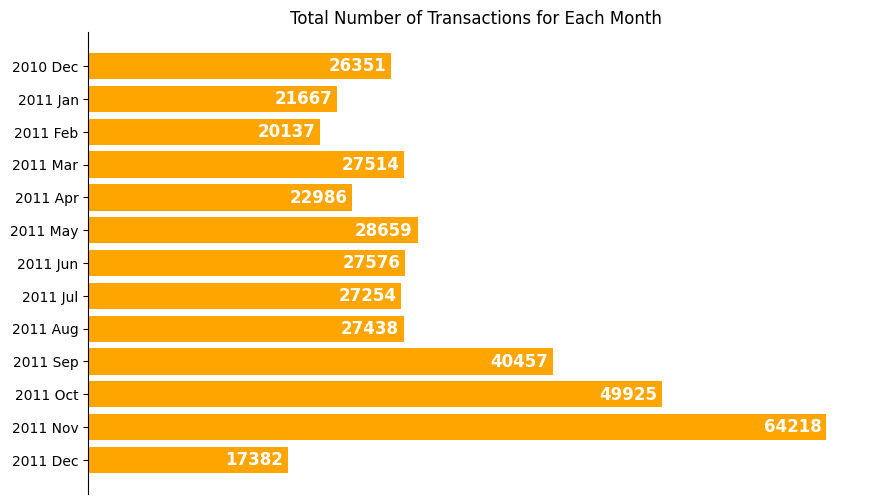

In [55]:
# Creating a new DataFrame by grouping rows of 'cleaned_retail_df'
monthly_transactions = (cleaned_retail_df
                        .groupby(cleaned_retail_df['InvoiceDate'].dt.to_period('M')) # Grouping by month AND year of transaction
                        .size() # Returns the number of rows for each group
                        .reset_index(name='Transactions') # Creates a new column for the number of rows for each group (transactions per month)
                        .sort_index(ascending=False))

# Reformatting dates for better readability
monthly_transactions['InvoiceDate'] = monthly_transactions['InvoiceDate'].dt.strftime('%Y %b')

print(monthly_transactions)

# Plotting transaction data
fig, ax = plt.subplots(figsize=(10, 6))

# Formatting for both axes as well as the horizontal bars
bars = ax.barh(monthly_transactions['InvoiceDate'].astype('str'), # Must be changed to 'str' so as to match dtype for 'Transactions'
               monthly_transactions['Transactions'],
               height=0.8,
               color='orange')

# Formatting for each bar label (number of transactions)
ax.bar_label(bars, 
             padding=-45, # Negative value makes the number appear inside the bar
             color='white', 
             fontsize=12,  
             fontweight='bold')

# Hiding the x-axis, along with the top, right, and bottom spines
ax.xaxis.set_visible(False)
ax.spines[['top', 'bottom', 'right']].set_visible(False)

ax.set_title('Total Number of Transactions for Each Month')
plt.show()

# Total Number of Transactions for Each Month
One of the most important factors a business must consider is the amount of transactions that are being handled over time. It is through this analysis of both size and frequency of transactions can the overall volume of transaction activity be effectively seen. Helping to visualize when the busiest times of a certain year were, periods of time where the company may experience a downturn, and thus draw conclusions on various business decisions to bolster the company at various points in time. 

In order to accurately and effectively display the number of transactions that occurred for each month, it is crucial to define exactly what a transaction is. In terms of the given dataset, a transaction pertains to any row of data inputted into the dataset. Any occurrence of the handling of money between the company and another party serves as a conduct of business and thus falls within the bounds of being a transaction. Whether it be a legitimate sale, refund, or fee payment, every action must be accounted for in order to most accurately scrutinize business expenditures and draw accurate conclusions to overall revenue/profits.

Another important detail about the given dataset was the fact that its collection spanned from December of 2010 to December of 2011. Thus, when analyzing the data, grouping all the transactions by month ALONE would not be accurate as there would need to be a distinction between transactions in the month of December for the year 2010 AND 2011. Thus, when viewing data on a monthly basis it is critical that the data must be grouped by both month and year. This same principle must also be applied for analyzing any aspect of the data, not just for transactions.

### Results
The top three months that saw the highest number of transactions was November, October, and September of 2011 in order from highest to lowest. Meanwhile, the three months that saw the least amount of transactions was January, February, and December of 2011 in order from highest to lowest.

What is most intriguing is the vast gap between the top three months and the rest of the data. This timespan in 2011 from September to November saw a total of 154600 transactions being recorded. When comparing against the whole dataset, these three months alone account for nearly 40% of all transactions recorded (approximately 38.50%). This gap is accompanied by a rising surge in transactions that took only 3 months to exponentially grow from August to November of 2011. Increasing over this period from 27438 transactions in August to 64218 transactions in November.

As for the rest of the months, the amount of transactions remains stagnant and experiences very little variance. From the months of December 2010 into August of 2011, the lowest amount of transactions recorded was 20137 and the highest was only 28659. 

Proving even more troublesome is the month of December in 2011, which saw only 17382 transactions recorded. However, this could be deduced to the fact that the data provided was not for the entirety of December but only went as far as December 9th.

In [56]:
monthly_revenue = (cleaned_retail_df
                   # Creating a new dataframe WITHOUT editing the original dataframe 
                   .assign(Revenue=lambda df: df['Quantity'] * df['UnitPrice'], # New 'Revenue' column multiplies the quantity by unit price and stores the product
                           Month=lambda df: df['InvoiceDate'].dt.to_period('M')) # New 'Month' column stores the month in which a sale occurred
                   .loc[lambda df: df['Revenue'] > 0] # Filters the dataframe to only keep rows where 'Revenue' is greater than 0
                   .groupby('Month', as_index=False)['Revenue'] # Grouping by month AND year of transaction
                   .sum()) # Collapses each group down to a single row by adding up all the 'Revenue' values within that month

# Reformatting dates for better readability
monthly_revenue['Month'] = monthly_revenue['Month'].dt.strftime('%Y %b')
print(monthly_revenue)

       Month      Revenue
0   2010 Dec   570422.730
1   2011 Jan   568101.310
2   2011 Feb   446084.920
3   2011 Mar   594081.760
4   2011 Apr   468374.331
5   2011 May   677355.150
6   2011 Jun   660046.050
7   2011 Jul   598962.901
8   2011 Aug   644051.040
9   2011 Sep   950690.202
10  2011 Oct  1035642.450
11  2011 Nov  1156205.610
12  2011 Dec   517190.440


In [57]:
monthly_profit = (cleaned_retail_df
                   # Creating a new dataframe WITHOUT editing the original dataframe 
                   .assign(Profit=lambda df: df['Quantity'] * df['UnitPrice'], # New 'Profit' column multiplies the quantity by unit price and stores the product
                           Month=lambda df: df['InvoiceDate'].dt.to_period('M')) # New 'Month' column stores the month in which a sale occurred
                   .groupby('Month', as_index=False)['Profit'] # Grouping by month AND year of transaction
                   .sum()) # Collapses each group down to a single row by adding up all the 'Profit' values within that month

# Reformatting dates for better readability
monthly_profit['Month'] = monthly_profit['Month'].dt.strftime('%Y %b')
print(monthly_profit)

       Month       Profit
0   2010 Dec   552372.860
1   2011 Jan   473731.900
2   2011 Feb   435534.070
3   2011 Mar   578576.210
4   2011 Apr   425222.671
5   2011 May   647011.670
6   2011 Jun   606862.520
7   2011 Jul   573112.321
8   2011 Aug   615078.090
9   2011 Sep   929356.232
10  2011 Oct   973306.380
11  2011 Nov  1126815.070
12  2011 Dec   341539.430


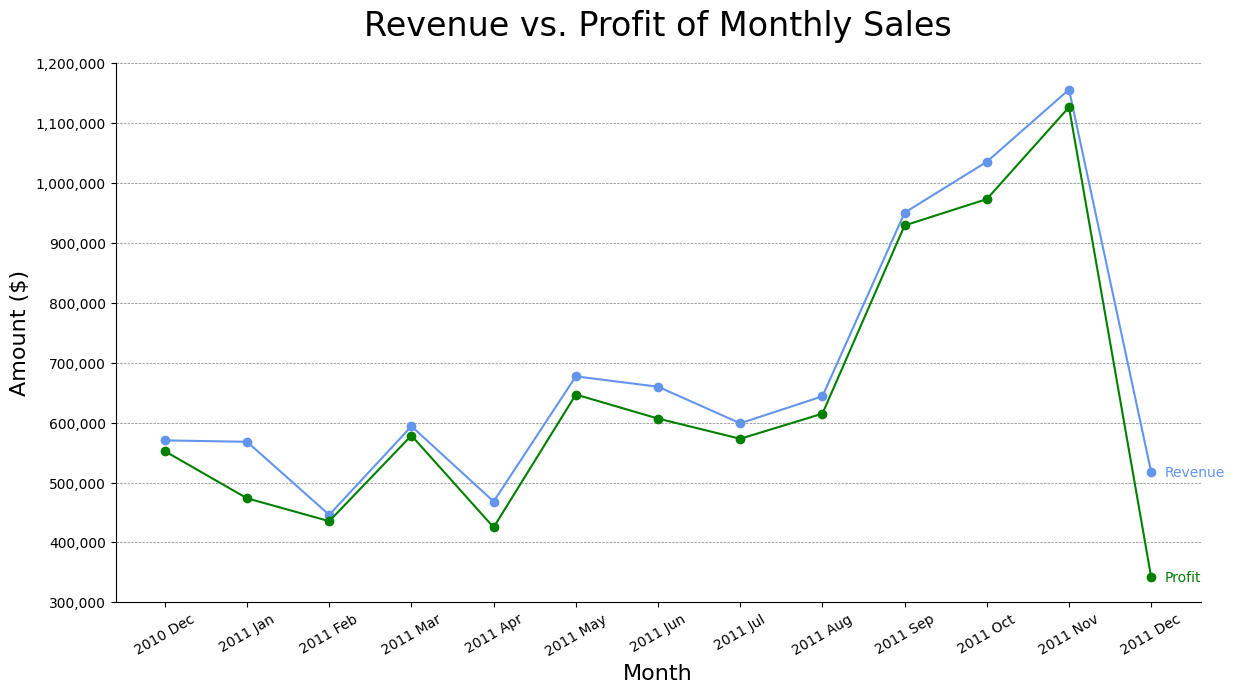

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(monthly_revenue['Month'], 
        monthly_revenue['Revenue'],
        color='cornflowerblue',
        marker='o')

ax.plot(monthly_profit['Month'], 
        monthly_profit['Profit'],
        color='green',
        marker='o')

ax.annotate('Revenue', 
            xy=(monthly_revenue['Month'].iloc[-1], monthly_revenue['Revenue'].iloc[-1]),
            xytext=(10, 0),
            textcoords='offset points',
            color='cornflowerblue', 
            fontsize=10, 
            va='center')

ax.annotate('Profit', 
            xy=(monthly_profit['Month'].iloc[-1], monthly_profit['Profit'].iloc[-1]),
            xytext=(10, 0),
            textcoords='offset points',
            color='green', 
            fontsize=10, 
            va='center')

ax.tick_params(axis='x', labelrotation=30)

ax.set_ybound(lower=300000, upper=1200000)
ax.yaxis.set_major_locator(ticker.MultipleLocator(100000))
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

ax.yaxis.grid(True, 
              linestyle='--', 
              linewidth=0.5,
              color='grey')

ax.set_xlabel('Month', fontsize=16)
ax.set_ylabel('Amount ($)', fontsize=16)
ax.spines[['top', 'right']].set_visible(False)

ax.set_title('Revenue vs. Profit of Monthly Sales', 
             fontsize=24, 
             pad=20)
plt.show()